In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
# SMOTE와 Pipeline (Data Leakage 방지용)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [4]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

### Cell 1: 데이터 로드 및 Feature Engineering

In [5]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 타겟 변수 라벨링

In [6]:
# 통합 이진 타겟(System_Failure) 생성: Protective Stop 또는 Grip Lost 발생 시 1
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())
# 0: Normal(정상), 1: Failure(고장)

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [7]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. 데이터 스케일링 (로지스틱 회귀 등 거리 기반 모델은 변수 스케일에 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 26)
테스트 데이터 크기: (1471, 26)


### Cell 4: Logistic Regression 학습 및 하이퍼파라미터 튜닝

In [8]:
# 1. Stratified K-Fold 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Imblearn Pipeline 구축 (Fold 내에서 SMOTE 적용 -> Logistic Regression 학습)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

# 3. 튜닝할 파라미터 그리드 (Pipeline 사용 시 모델명__파라미터명 형태로 지정)
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['saga']
}

# 4. GridSearchCV 실행 (데이터 불균형을 고려해 scoring을 'f1_macro'로 설정)
print("--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

# 5. 최적 파라미터 및 결과 확인
print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('lr__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • C: 10
  • penalty: l2
  • solver: saga

최고 교차 검증 F1-Macro 점수: 0.4819


### Cell 5: 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [9]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 파이프라인(SMOTE+LR) 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(
            C=params.get('lr__C', 1.0),
            penalty=params.get('lr__penalty', 'l2'),
            solver=params.get('lr__solver', 'saga'),
            random_state=42, max_iter=1000
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 평가지표 계산
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환
    c_val = params.get('lr__C', '-')
    pen_val = params.get('lr__penalty', '-')
    sol_val = params.get('lr__solver', '-')
    param_short = f"C={c_val}, P={pen_val}, S={sol_val}"
    
    # 결과 저장
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,파라미터 설정
0,1,0.4819,0.4942,0.5049,-0.0108,0.642930,0.649898,"C=10, P=l2, S=saga"
1,2,0.4818,0.4925,0.5045,-0.0120,0.640721,0.649218,"C=1, P=l1, S=saga"
2,3,0.4810,0.4948,0.5082,-0.0134,0.644290,0.653297,"C=100, P=l1, S=saga"
3,4,0.4809,0.4945,0.5082,-0.0137,0.643950,0.653297,"C=100, P=l2, S=saga"
4,5,0.4809,0.4947,0.5082,-0.0135,0.644120,0.653297,"C=10, P=l1, S=saga"
5,6,0.4774,0.4887,0.5069,-0.0181,0.636472,0.656016,"C=1, P=l2, S=saga"
6,7,0.4655,0.4806,0.4932,-0.0126,0.623555,0.634942,"C=0.1, P=l1, S=saga"
7,8,0.4639,0.4779,0.4910,-0.0131,0.619646,0.631543,"C=0.1, P=l2, S=saga"
8,9,0.4549,0.4709,0.4823,-0.0114,0.606050,0.617947,"C=0.01, P=l2, S=saga"
9,10,0.4504,0.4570,0.4791,-0.0221,0.588375,0.608430,"C=0.01, P=l1, S=saga"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [10]:
print("\n" + "="*50)
target_rank = 1  # 분석하고 싶은 순위를 입력하세요 (예: 1, 2, 3...)
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

# 1. top_models에서 원하는 순위의 파라미터 추출
selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('lr__', '')}: {value}")

# 2. 추출한 파라미터로 모델 재학습
selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(
        C=selected_params.get('C', 1.0),
        penalty=selected_params.get('penalty', 'l2'),
        solver=selected_params.get('solver', 'saga'),
        random_state=42, class_weight='balanced', max_iter=1000
    ))
])
selected_model.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_train_pred_selected = selected_model.predict(X_train_scaled)
y_test_pred_selected = selected_model.predict(X_test_scaled)
y_test_prob_selected = selected_model.predict_proba(X_test_scaled)[:, 1]

# 4. 평가지표 출력 함수
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

# 5. Train / Test 결과 출력
print_metrics(y_train, y_train_pred_selected, "Train")
print_metrics(y_test, y_test_pred_selected, "Test")

y_test_pred = y_test_pred_selected
y_test_prob = y_test_prob_selected


--- [상세 분석] 1위 모델 최종 평가지표 ---

[선택된 1위 모델의 하이퍼파라미터]
  • C: 10
  • penalty: l2
  • solver: saga

[Train 데이터 평가]
Accuracy (정확도) : 0.6365
F1-Macro Score    : 0.488730

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.63      0.76      5470
 1 (Failure)       0.13      0.70      0.21       414

    accuracy                           0.64      5884
   macro avg       0.55      0.67      0.49      5884
weighted avg       0.91      0.64      0.72      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.6560
F1-Macro Score    : 0.506860

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.65      0.78      1367
 1 (Failure)       0.14      0.75      0.24       104

    accuracy                           0.66      1471
   macro avg       0.56      0.70      0.51      1471
weighted avg       0.91      0.66      0.74      1471



### Cell 7: 오차 행렬(Confusion Matrix) 및 중요도 시각화

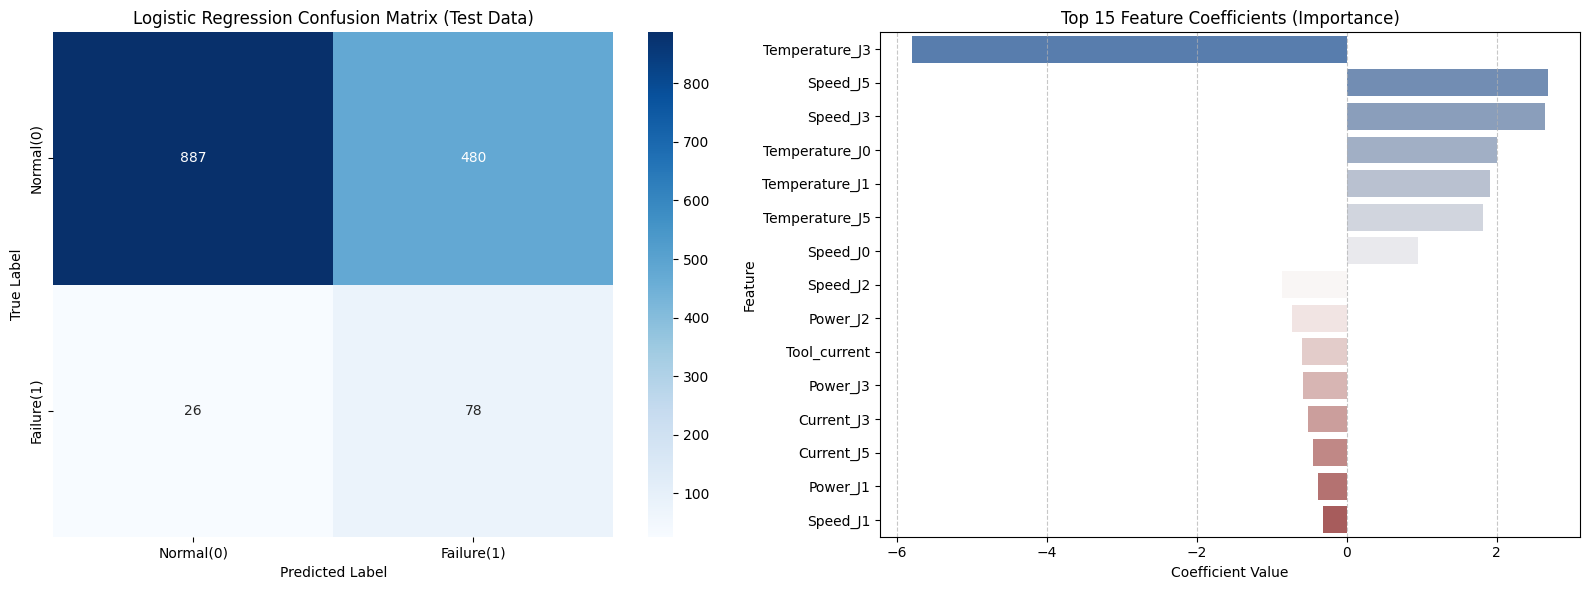

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])
axes[0].set_title(f'Logistic Regression Confusion Matrix (Test Data)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Feature Importance (Coefficient)
lr_step = selected_model.named_steps['lr']
coefs = pd.DataFrame({
    'Feature': input_cols,
    'Coefficient': lr_step.coef_[0]
})
coefs['Abs_Coefficient'] = coefs['Coefficient'].abs()
coefs = coefs.sort_values(by='Abs_Coefficient', ascending=False).head(15) # 상위 15개만

sns.barplot(x='Coefficient', y='Feature', data=coefs, palette='vlag', ax=axes[1])
axes[1].set_title('Top 15 Feature Coefficients (Importance)')
axes[1].set_xlabel('Coefficient Value')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Cell 8: 피처 선택(Feature Selection) 확인용 코드

In [12]:
# L1 페널티 모델의 가중치 0 (Feature Selection) 확인하기

# 확인하고 싶은 순위 (사진 기준 2위나 3위 입력)
target_rank_l1 = 2

print("\n" + "="*60)
print(f"--- [L1 규제 분석] {target_rank_l1}위 모델의 특성 선택(Feature Selection) 결과 ---")
print("="*60)

# 1. 원하는 순위의 파라미터 추출
selected_row_l1 = top_models[top_models['rank_test_score'] == target_rank_l1].iloc[0]
selected_params_l1 = selected_row_l1['params']

print(f"\n[선택된 {target_rank_l1}위 모델의 하이퍼파라미터]")
for param, value in selected_params_l1.items():
    print(f"  • {param.replace('lr__', '')}: {value}")

if selected_params_l1.get('lr__penalty') != 'l1':
    print("\n⚠️ 경고: 선택하신 모델은 L1 페널티를 사용하지 않아 가중치가 완벽히 0이 되지 않을 수 있습니다.")

# 2. 모델 재학습 (파이프라인)
model_l1 = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    # 앞서 ENN을 추가하셨다면 아래 줄 주석 해제
    # ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')), 
    ('lr', LogisticRegression(
        C=selected_params_l1.get('lr__C', 1.0),
        penalty=selected_params_l1.get('lr__penalty', 'l1'), # L1 강제 지정
        solver=selected_params_l1.get('lr__solver', 'saga'),
        random_state=42, class_weight='balanced', max_iter=1000
    ))
])
model_l1.fit(X_train_scaled, y_train)

# 3. 로지스틱 회귀 계수 추출
lr_step_l1 = model_l1.named_steps['lr']
coefs_l1 = pd.DataFrame({
    'Feature': input_cols,
    'Coefficient': lr_step_l1.coef_[0]
})

# 4. 가중치가 0인 피처와 살아남은 피처 분리
zero_coefs = coefs_l1[coefs_l1['Coefficient'] == 0]
non_zero_coefs = coefs_l1[coefs_l1['Coefficient'] != 0].sort_values(by='Coefficient', key=abs, ascending=False)

print(f"\n🔥 [삭제된 피처] 가중치가 정확히 0이 된 피처: {len(zero_coefs)}개")
if len(zero_coefs) > 0:
    for f in zero_coefs['Feature']:
        print(f"  - {f}")
else:
    print("  - 없음 (모든 피처가 사용되었습니다)")

print(f"\n🌟 [살아남은 피처] 가중치가 0이 아닌 피처: {len(non_zero_coefs)}개 (절대값 크기순 정렬)")
for _, row in non_zero_coefs.iterrows():
    print(f"  - {row['Feature']:<20} : {row['Coefficient']:.4f}")


--- [L1 규제 분석] 2위 모델의 특성 선택(Feature Selection) 결과 ---

[선택된 2위 모델의 하이퍼파라미터]
  • C: 1
  • penalty: l1
  • solver: saga

🔥 [삭제된 피처] 가중치가 정확히 0이 된 피처: 0개
  - 없음 (모든 피처가 사용되었습니다)

🌟 [살아남은 피처] 가중치가 0이 아닌 피처: 26개 (절대값 크기순 정렬)
  - Temperature_J3       : -10.9191
  - Temperature_J4       : 3.3544
  - Temperature_J1       : 3.2728
  - Speed_J5             : 2.8367
  - Speed_J3             : 2.8211
  - Temperature_J0       : 2.2671
  - Temperature_J5       : 2.0206
  - Speed_J0             : 1.0265
  - Speed_J2             : -0.8672
  - Power_J2             : -0.7284
  - Tool_current         : -0.5914
  - Power_J3             : -0.5858
  - Current_J3           : -0.5171
  - Current_J5           : -0.4477
  - Power_J1             : -0.4205
  - Speed_J1             : -0.3585
  - Power_J0             : -0.2700
  - Current_J0           : 0.2265
  - Current_J2           : 0.1542
  - Power_J4             : 0.1427
  - Power_J5             : 0.1297
  - Speed_J4             : -0.0945
  - Current_J4     